In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

In [16]:
df=pd.read_csv("./ventas.csv",header=None,names=['ventas'])
df


,ventas
0,120
1,135
2,98
3,145
4,160
5,110
6,125
7,130
8,115
9,140


In [17]:
# El 50% de los días las ventas están por debajo de 131 y el otro 50% por encima. 
# La mediana (131) es muy similar a la media (131.37), 
# lo que indica que los datos no tienen valores extremos que distorsionen el promedio.
mediana = df['ventas'].median()
print(f"Mediana: {mediana:.2f}")


Mediana: 131.00


In [18]:
# El valor que más se repite es 118, apareciendo dos veces. Significa que hubo dos días
# que se tuvo la misma venta.
moda = df['ventas'].mode()[0]
veces= (df['ventas']==moda).sum()
print(moda,' ',veces)

118   2


In [19]:
# Q1 (115.75): El 25% de los días las ventas son menores a 115.75 (los días malos)
# Q2 (131.00): El 50% de los días las ventas son menores a 131 (días promedio)
# Q3 (149.50): El 75% de los días las ventas son menores a 149.50 (los días buenos)
q1 = df['ventas'].quantile(.25) # Primer cuartil (25%)
q2 = df['ventas'].quantile(.50)   # Segundo cuartil (50%) = mediana
q3 = df['ventas'].quantile(.75)  # Tercer cuartil (75%)
print(f"Q1 (25%): {q1:.2f}")
print(f"Q2 (50%): {q2:.2f}")  # Igual que la mediana
print(f"Q3 (75%): {q3:.2f}")

Q1 (25%): 115.75
Q2 (50%): 131.00
Q3 (75%): 149.50


In [26]:
# El 50% central de los datos (desde Q1 hasta Q3) tienen una dispersión de 33.75
# Esto nos dice que la mayoría de los días las ventas varían en un rango de 33.75.
iqr = q3 - q1
print(f"IQR: {iqr:.2f}")

IQR: 33.75


In [22]:
# La varianza de 576.83² (en unidades al cuadrado) mide la dispersión promedio
# de las ventas respecto a la media. Al estar en unidades cuadradas, es difícil de interpretar directamente.
varianza = df['ventas'].var()
print(f"Varianza: {varianza:.2f}") 

Varianza: 596.72


In [23]:
# En promedio, las ventas diarias se desvían 24.43 del promedio de 131.37.
# Un día "normal" está entre $107.61 y $155.8 (media ± 1 desviación)
desviacion_std = df['ventas'].std()
print(f"Desviación Estándar:{desviacion_std:.2f}")

Desviación Estándar:24.43


In [24]:
# En promedio, las ventas diarias se desvían 24.43 del promedio de 131.37.
# Un día "normal" está entre $107.61 y $155.8 (media ± 1 desviación)
desviacion_std = df['ventas'].std()
print(f"Desviación Estándar:{desviacion_std:.2f}")

Desviación Estándar:24.43


In [27]:
# Las ventas van desde el día más bajo (75) hasta el más alto (180), una diferencia de 105.
rango = df['ventas'].max() - df['ventas'].min()
print(f"Rango: {rango:.2f}")

Rango: 105.00


In [33]:
# El promedio de ventas diarias es de 131.37. Esto significa que, en promedio, 
# la tienda vende 131.37 cada día.
media = df['ventas'].mean()
print(f"Media: {media:.2f}")

Media: 131.37


In [34]:
# Coeficiente de variación
cv = (desviacion_std / media) * 100
print(f" COEFICIENTE DE VARIACIÓN: {cv:.1f}%")
print(f"  (Indica que la variabilidad es {'alta' if cv > 30 else 'moderada' if cv > 15 else 'baja'})")

 COEFICIENTE DE VARIACIÓN: 18.6%
  (Indica que la variabilidad es moderada)


In [35]:
# Asimetría (skewness)
asimetria = skew(np.array(df['ventas']))
print(f"ASIMETRÍA: {asimetria:.2f}")
if asimetria > 0.5:
    print("  Distribución con sesgo positivo (cola a la derecha)")
elif asimetria < -0.5:
    print("  Distribución con sesgo negativo (cola a la izquierda)")
else:
    print("  Distribución aproximadamente simétrica")

ASIMETRÍA: -0.13
  Distribución aproximadamente simétrica


In [36]:
# Análisis de percentiles adicionales
datos=np.array(df['ventas'])
percentiles = [10, 25, 50, 75, 90]
valores_percentiles = np.percentile(datos, percentiles)

print("PERCENTILES CLAVE:")
for p, v in zip(percentiles, valores_percentiles):
    print(f"  P{p}: {v:.2f}")

# Identificar días atípicos (outliers)
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
outliers = datos[(datos < limite_inferior) | (datos > limite_superior)]

print(f" DÍAS ATÍPICOS:")
print(f"  Límite inferior: {limite_inferior:.2f}")
print(f"  Límite superior: {limite_superior:.2f}")
if len(outliers) > 0:
    print(f"  Días atípicos: {outliers}")
else:
    print("  No se detectaron días atípicos")

# Interpretación gerencial
print("INTERPRETACIÓN PARA EL NEGOCIO:")
print(f"  1. Ventas promedio diarias: {media:.2f}")
print(f"  2. Días típicos: entre {q1:.2f} y {q3:.2f} (50% de los días)")
print(f"  3. Variabilidad: ±${desviacion_std:.2f} del promedio")
print(f"  4. Los días con ventas superiores a {limite_superior:.2f} son excepcionales")
print(f"  5. Los días con ventas inferiores a {limite_inferior:.2f} requieren análisis")

PERCENTILES CLAVE:
  P10: 101.60
  P25: 115.75
  P50: 131.00
  P75: 149.50
  P90: 160.50
 DÍAS ATÍPICOS:
  Límite inferior: 65.12
  Límite superior: 200.12
  No se detectaron días atípicos
INTERPRETACIÓN PARA EL NEGOCIO:
  1. Ventas promedio diarias: 131.37
  2. Días típicos: entre 115.75 y 149.50 (50% de los días)
  3. Variabilidad: ±$24.43 del promedio
  4. Los días con ventas superiores a 200.12 son excepcionales
  5. Los días con ventas inferiores a 65.12 requieren análisis


/tmp/ipykernel_4768/2712097440.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(datos, vert=False)


Text(0.5, 1.0, 'Resumen Estadístico')

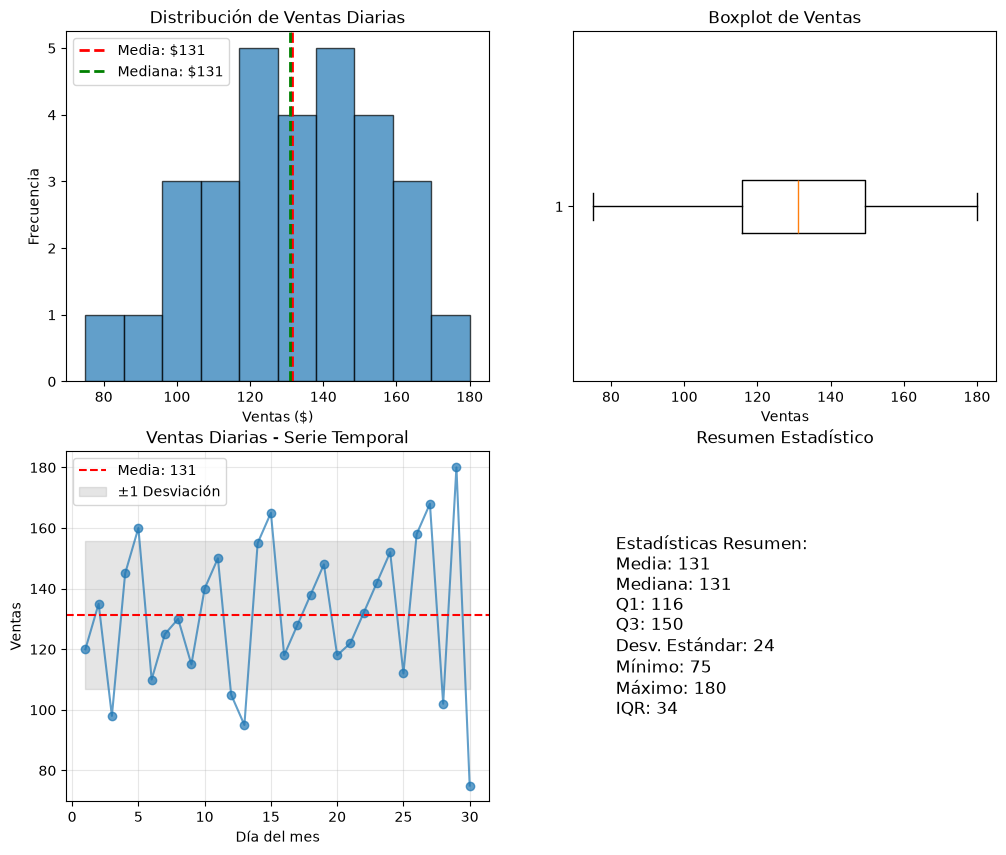

In [37]:
import matplotlib.pyplot as plt

# Crear figura con varios subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histograma con medidas de tendencia central
axes[0, 0].hist(datos, bins=10, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Media: ${media:.0f}')
axes[0, 0].axvline(mediana, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: ${mediana:.0f}')
axes[0, 0].set_title('Distribución de Ventas Diarias')
axes[0, 0].set_xlabel('Ventas ($)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

# Boxplot
axes[0, 1].boxplot(datos, vert=False)
axes[0, 1].set_title('Boxplot de Ventas')
axes[0, 1].set_xlabel('Ventas')

# Serie temporal
dias = np.arange(1, 31)
axes[1, 0].plot(dias, datos, marker='o', linestyle='-', alpha=0.7)
axes[1, 0].axhline(media, color='red', linestyle='--', label=f'Media: {media:.0f}')
axes[1, 0].fill_between(dias, media - desviacion_std, media + desviacion_std, 
                        alpha=0.2, color='gray', label='±1 Desviación')
axes[1, 0].set_title('Ventas Diarias - Serie Temporal')
axes[1, 0].set_xlabel('Día del mes')
axes[1, 0].set_ylabel('Ventas')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Resumen estadístico
stats_text = f"""
Estadísticas Resumen:
Media: {media:.0f}
Mediana: {mediana:.0f}
Q1: {q1:.0f}
Q3: {q3:.0f}
Desv. Estándar: {desviacion_std:.0f}
Mínimo: {np.min(datos):.0f}
Máximo: {np.max(datos):.0f}
IQR: {iqr:.0f}
"""
axes[1, 1].text(0.1, 0.5, stats_text, transform=axes[1, 1].transAxes,
                fontsize=12, verticalalignment='center')
axes[1, 1].axis('off')
axes[1, 1].set_title('Resumen Estadístico')